# Исследование заведений рынка общественного питания Москвы

## Цели и задачи проекта
**Цель:** Провести исследовательский анализ данных заведений общественного питания в Москве.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить категории заведений;
    - изучить заведения в разрезе админитративных районов гор. Москва;
    - изучить сетевые и несетевые заведения;
    - проанализировать количество посадочных мест в заведениях;
    - исследовать рейтинг заведений;
    - изучить взаимосвязь рейтинга заведения с другими данными;
    - определить ТОП-15 популярных сетей;
    - изучить вариации среднего чека.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные о заведениях общественного питания в Москве. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info.csv`
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- seats — количество посадочных мест.


### Описание датасета `rest_price.csv`
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    - и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


## Структура проекта

1. Цели и задачи проекта.
2. Данные.
3. Структура.
4. Загрузка данных.
5. Проверка данных.
6. Предобработка данных.
7. Поиск дубликатов.
8. Исследовательский анализ данных.
9. Выводы.

---

## Загрузка данных и знакомство с ними

Загрузим необходимые библиотеки для анализа данных и данные из датасетов `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Затем выведем основную информацию о данных с помощью метода `info()` и первые строки датафрейма.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные rest_info и clients_df
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

## Проверка ошибок в данных и их предобработка
### Названия столбцов и тип данных

Познакомимся с данными датасета `rest_info`

In [3]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим номинальное и процентное количество пропусков
print(rest_info.isna().sum())
print(round(rest_info.isna().sum()/rest_info.shape[0]*100,1))

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64
id           0.0
name         0.0
category     0.0
address      0.0
district     0.0
hours        6.4
rating       0.0
chain        0.0
seats       43.0
dtype: float64


Датасет `rest_info` содержит 8406 строк и 9 столбцов.
- Названия столбцов написаны корректно
- 6 столбцов имеют тип данных object: id, name, category, address, district, hours. Тип данных выбран корректно
- 2 столба имеют вещественный тип float64: rating и seats. Столбец seats показывает количество посадочных мест и не может быть дробным числом, соответственно можно перевести его в integer
- 1 столбец имеет целочисленный тип данных chain, который по сути является бинарным и должен содержать себе только 0 или 1.
- Столбец hours содержит 536 пропусков (6.4%)
- Столбец seats содержит 3611 пропусков (43.0%). Большая доля пропусков в этом столбце может помешать точным расчетам и анализу.

Познакомимся с данными датасета `rest_price`

In [6]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# Выводим номинальное и процентное количество пропусков
print(rest_price.isna().sum())
print(round(rest_price.isna().sum()/rest_info.shape[0]*100,1))

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64
id                    0.0
price                 8.8
avg_bill              2.9
middle_avg_bill      10.8
middle_coffee_cup    41.9
dtype: float64


Датасет `rest_price` содержит 4058 строк и 5 столбцов.
- Названия столбцов написаны корректно
- 3 столбца имеют тип данных object: id, price, avg_bill. Тип выбран верно
- 2 столбца имеют тип данных float64. Можно предположить, что средний чек заведения никогда не будет указан с точностью до десятичных долей и поэтому типы данных этих столбцов могли быть integer. Но мы не знает этого наверняка, поэтому не будем изменять тип данных.
- Столбец price имеет 743 пропуска (8.8%)
- Столбец avg_bill имеет 242 пропуска (2.9%)
- Столбец middle_avg_bill имеет 909 пропусков (10.8%). В описании было сказано, что пропуски в данном столбце возможны при отсутствии необходимых данных в столбце avg_bill.
- Столбец middle_coffee_cup имеет 3523 пропуска (41.9%). В описании было сказано, что пропуски в данном столбце возможны при отсутствии необходимых данных в столбце avg_bill.

---

### Промежуточный вывод

Датасет `rest_info` содержит 8406 строк `rest_price` содержит 4058 строк, соответственно, при объединении датасетов вместе, как минимум 4348 (51%) заведений останутся без информации о ценовых категориях. Удалять такое большое количество информации нельзя, поэтому просто объединим датасеты, сохранив количество строк `rest_info` по столбу `id`. К тому же, для решения почти всех аналитических задач в данном проекте, достаточно информации из датасета `rest_info`.

### Подготовка единого датафрейма


In [9]:
# Объединим данные двух датасетов в один, с которым продолжим работу.
df=rest_info.merge(rest_price, how='left', on='id')

In [10]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


## Предобработка данных

Выполним преобрзование типа данных столбца `seats` в integer, потому что число посадочных мест может быть только целочисленным.
Остальные типы данных в датасете выбраны корректно и не требуют корректировок.

In [11]:
# Так как мы заведомо знаем, что в столбце есть пропуски, применяем тип 'Int64' с поддеркжой NA.
df['seats']=df['seats'].astype('Int64')

In [12]:
# Еще раз выводим все типы данных получившегося датасета
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), float64(3), int64(1), object(8)
memory usage: 862.1+ KB


In [13]:
# Выводим еще раз номинальное и процентное количество пропусков, теперь уже в объединенном датасете df
print(df.isna().sum())
print(round(df.isna().sum()/df.shape[0]*100,1))

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64
id                    0.0
name                  0.0
category              0.0
address               0.0
district              0.0
hours                 6.4
rating                0.0
chain                 0.0
seats                43.0
price                60.6
avg_bill             54.6
middle_avg_bill      62.5
middle_coffee_cup    93.6
dtype: float64


- Количество пропусков в столбцах `hours` и `seats` осталось прежним: 536 и 3611 соответственно
- Количество пропусков в столбцах из датасета `rest_price` увеличилось, потому что мы изначально обозначили, что в этом датасете на 4348 строк меньше.
    - `price`: 5091 пропусков (60.6%)
    - `avg_bill`: 4590 пропусков (54.6%)
    - `middle_avg_bill`:  5257 пропусков (62.5%)
    - `middle_coffee_cup`: 7871 пропусков (93.6%)

## Явные и неявные дубликаты в данных
Проверим данные на наличие явных и неявных дубликатов. Для этого сначала нормализуем данные в текстовых столбцах.

In [14]:
# Приводим к нижнему регистру значения в столбцах id, name, address
for col in ['id','name', 'address']:
    df[col]=df[col].str.lower()

In [15]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id`, `name` и, возможно, `address` должны быть уникальными

In [16]:
# Проверяем неявные дубликаты в датафрейме df по столбцу id
df.duplicated(subset='id').sum()

np.int64(0)

In [17]:
# Проверяем неявные дубликаты в датафрейме df по столбцу name
df.duplicated(subset='name').sum()

np.int64(2894)

2894 строк не являются дубликатами, потому что в датасете присутствуют:
- сетевые магазины
- возможные магазины с одинаковыми названиями
- строки, где название прописано просто как "кафе", "шашлычная" и т.п.

Поэтому для выявления дубликатов в названиях можно посмотреть строки, где повторяются две строки - `name` и `address`:

In [18]:
df[df.duplicated(subset=['name', 'address'],keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN


Выявили 4 дубликата:
- Один дубликат не имеет конкретного названия, в поле `name` указано просто "кафе", у него нет конкретного адреса и указаны разные часы работы. Соответственно, это могут быть разные заведения и удалять их нельзя.
- В трех дубликатах значения в столбце `chain` разнятся. Для того, чтобы определить какие из строк можно удалить, проверим, являются ли эти магазины сетевыми. Для этого выведем все повторы и отсортируем для наглядности:

In [19]:
# Выводим повторы и сортируем
df[df['name'].isin(['more poke', 'хлеб да выпечка', 'раковарня клешни и хвосты'])].sort_values('name')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
6088,1cd73aca53414d65a7744da3d1c93832,more poke,ресторан,"москва, духовской переулок, 19",Южный административный округ,"ежедневно, 10:00–22:00",4.4,1,<NA>,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,раковарня клешни и хвосты,"бар,паб","москва, братиславская улица, 12",Юго-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40,средние,Цена бокала пива:150–250 ₽,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,хлеб да выпечка,кофейня,"москва, каширское шоссе, 61г",Южный административный округ,"ежедневно, 09:00–22:00",4.5,1,<NA>,NaN,NaN,NaN,NaN


У всех трех магазинов есть еще другие адреса, значит можно удалить дубликаты строк со значением chain=0, т.к. это значение не корректно:

In [20]:
# удаляем дубликаты, выбрав те строки, где некорректно указано поле chain
names_dup = [
    'more poke',
    'хлеб да выпечка',
    'раковарня клешни и хвосты'
]
df = df.drop(
    df.loc[
        df['name'].isin(names_dup) &
        (df['chain'] == 0)
    ].index
)

In [21]:
# Проверим уникальные значения в категориальном столбце category
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

Дубликатов в столбце `category` нет, все значения уникальны.

In [22]:
# Проверим уникальные значения в категориальном столбце chain
df['chain'].unique()

array([0, 1])

В столбце `chain` тоже все в порядке

In [23]:
# Проверим уникальные значения в категориальном столбце district
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

В столбце district все округа уникальны

In [24]:
# Проверим уникальные значения в категориальном столбце rating
df['rating'].unique()

array([5. , 4.5, 4.6, 4.4, 4.7, 4.8, 4.3, 4.9, 4.2, 4.1, 4. , 3.8, 3.9,
       3.7, 3.6, 2.8, 2.7, 3.1, 1.5, 2. , 1.4, 3.3, 3.5, 3.2, 2.9, 3. ,
       3.4, 2.3, 2.2, 2.5, 2.6, 1.7, 1. , 1.1, 2.4, 1.3, 1.2, 2.1, 1.8,
       1.9, 1.6])

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [25]:
# Добавляем новый бинарный столбец-указатель работы заведения 24/7:
df['is_24_7'] = (
    (
    df['hours'].str.contains('ежедневно', na=False) &
    df['hours'].str.contains('круглосуточно', na=False)
    ) |
    df['hours'].str.contains('24/7', na=False)
)

In [26]:
# Проверяем добавился ли новый столбец и как отображается
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,False


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8403 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8403 non-null   object 
 1   name               8403 non-null   object 
 2   category           8403 non-null   object 
 3   address            8403 non-null   object 
 4   district           8403 non-null   object 
 5   hours              7868 non-null   object 
 6   rating             8403 non-null   float64
 7   chain              8403 non-null   int64  
 8   seats              4792 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8403 non-null   bool   
dtypes: Int64(1), bool(1), float64(3), int64(1), object(8)
memory usage: 935.5+ KB


---

### Промежуточный вывод

В ходе предобработки был проверен датасет df на наличие явных и неявных дубликатов. Было обнаружено и удалено 3 дубликата.

Для дальнейшего анализа был добавлен новый столбец, который укажет заведения, работающие 24/7.

## 3. Исследовательский анализ данных
Проведем исследовательский анализ исходных данных.

---

### Задача 1

Определим категории заведений представлены в данных. Исследуем количество объектов общественного питания по каждой категории. Результаты сопроводим подходящей визуализацией.

In [28]:
# Выведем количество заведений по каждой категории
df['category'].value_counts()

category
кафе               2377
ресторан           2041
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

In [29]:
# Выведем процентное соотношение каждой категории к общему числу заведений
df['category'].value_counts()/df.shape[0]*100

category
кафе               28.287516
ресторан           24.288944
кофейня            16.815423
бар,паб             9.103891
пиццерия            7.533024
быстрое питание     7.176009
столовая            3.748661
булочная            3.046531
Name: count, dtype: float64

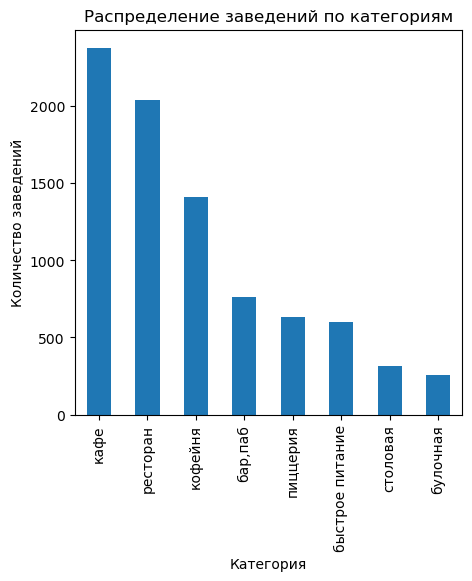

In [30]:
# Визуализируем на диаграмме Количество заведений по категориям
df['category'].value_counts().plot(
    kind='bar',
    figsize=(5,5),
    xlabel='Категория',
    ylabel='Количество заведений',
    title='Распределение заведений по категориям'
);

ТОП-3 категорий по количеству заведений в Москве:
1. Кафе - 2377 заведения (28.3%)
2. Ресторан - 2041 заведение (24.3%)
3. Кофейня - 1413 заведений (16.8%)
Меньше всего столовых (3.7%) и булочных (3%)

---

### Задача 2

Посмотрим какие административные районы Москвы присутствуют в данных и исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

In [31]:
# Выведем количество заведений по административным районам Москвы
df['district'].value_counts()

district
Центральный административный округ         2242
Северный административный округ             899
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

In [32]:
# Выведем процентное соотношение количества заведений по административным районам Москвы
df['district'].value_counts()/df.shape[0]*100

district
Центральный административный округ         26.680947
Северный административный округ            10.698560
Южный административный округ               10.615256
Северо-Восточный административный округ    10.591455
Западный административный округ            10.115435
Восточный административный округ            9.496608
Юго-Восточный административный округ        8.496965
Юго-Западный административный округ         8.437463
Северо-Западный административный округ      4.867309
Name: count, dtype: float64

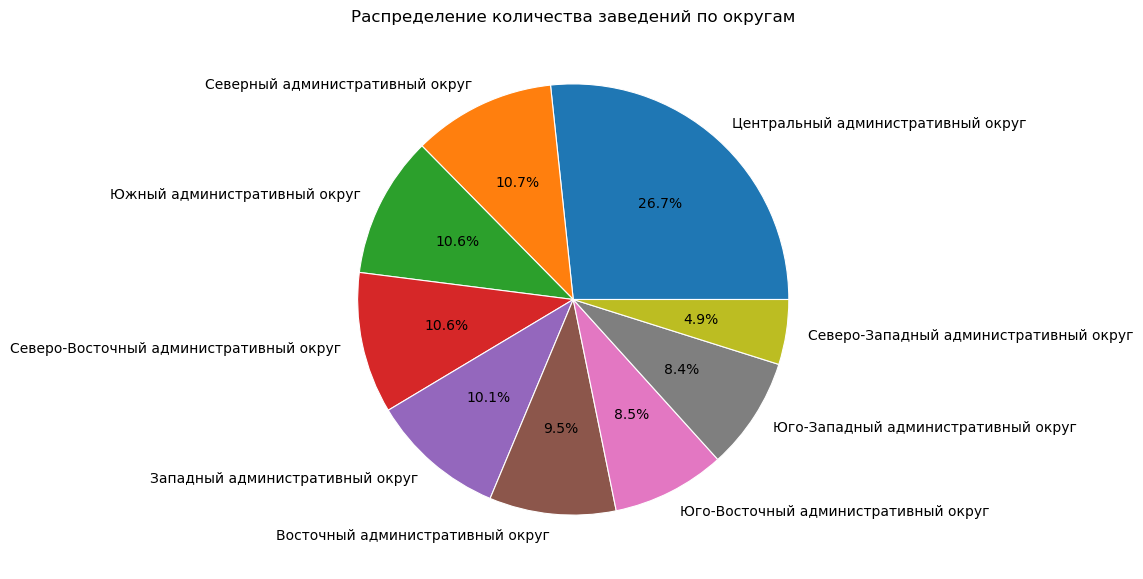

In [33]:
# Визуализируем на круговой диаграмме распределение количества заведений по административным округам
df['district'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    ylabel='',
    title='Распределение количества заведений по округам',
    wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'}
);

In [34]:
# Выводим количество заведений по категориям в разрезе ЦАО
df.loc[df['district'] == 'Центральный административный округ', 'category'].value_counts()

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

In [35]:
# Выводим процентное соотношение категорий в ЦАО
df.loc[df['district'] == 'Центральный административный округ', 'category'].value_counts()/df.loc[df['district'] == 'Центральный административный округ', 'category'].shape[0]*100

category
ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: count, dtype: float64

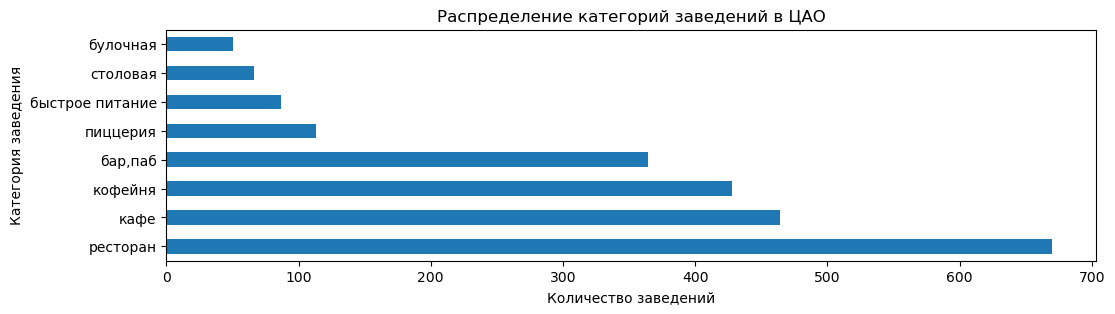

In [36]:
# Визуализируем на горизонтальной диаграмме распределение категорий заведений в ЦАО
df.loc[df['district'] == 'Центральный административный округ', 'category'].value_counts().plot(
    kind='barh',
    figsize=(12,3),
    xlabel='Количество заведений',
    ylabel='Категория заведения',
    title='Распределение категорий заведений в ЦАО'
);

В данных присуствуют 9 из 12 округов Москвы. Большинство заведений (26.7%) сосредоточего в ЦАО - 2242. Меньше всего в СЗАО - 409 (4.8%). Остальные округа имеют примерно одинаковое распределение заведений, с разбросом в 2%.

В ЦАО в основном представлены: рестораны 670 (29.8%), кафе 464 (20.7%), кофейни 428 (19.1%), бары 364 (16.2%). Остальные категории представлены ниже 5%.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Опредеим каких заведений больше — сетевых или несетевых, какие категории заведений чаще являются сетевыми.

In [37]:
# Выведем общее количество сетевых и не сетевых заведений
# 0 - заведение не сетевое, 1 - заведение сетевое
df.groupby('chain')['id'].count()

chain
0    5198
1    3205
Name: id, dtype: int64

In [38]:
# Выведем соотношение сетевых и не сетевых заведений в разрезе категорий заведений, отсротируем по возрастанию
task_chain=pd.pivot_table(
    df,
    index='category',
    columns='chain',
    values='name',
    aggfunc='count'
)
task_chain['ratio']=round(task_chain[0]/task_chain[1],2)
task_chain.sort_values(by=[0,1], ascending=False)

chain,0,1,ratio
category,,,
кафе,1598,779,2.05
ресторан,1311,730,1.80
кофейня,693,720,0.96
"бар,паб",596,169,3.53
быстрое питание,371,232,1.60
пиццерия,303,330,0.92
столовая,227,88,2.58
булочная,99,157,0.63


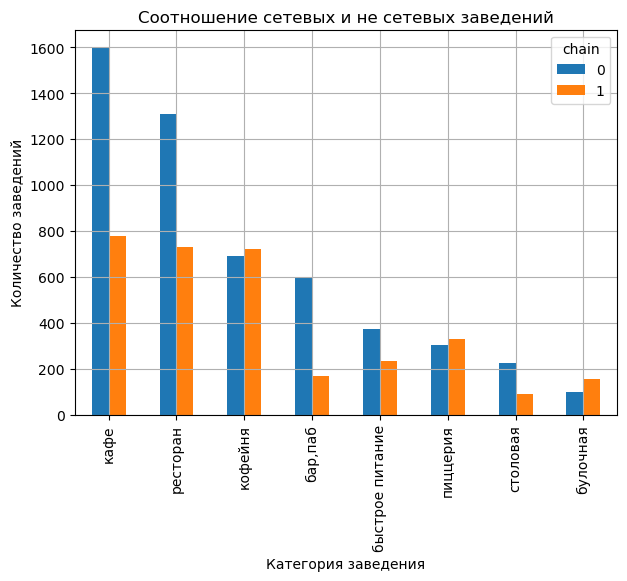

In [39]:
# Визуализируем на диаграмме соотношение сетевых и не сетевых заведений по категориям
task_chain.iloc[:, [0, 1]].sort_values(by=[0,1], ascending=False).plot(
    kind='bar',
    figsize=(7,5),
    xlabel='Категория заведения',
    ylabel='Количество заведений',
    title='Соотношение сетевых и не сетевых заведений',
    grid=True
);

In [40]:
# Выведем соотношение кагероий заведений только среди сетевых, отсортируем по возрастанию
task_chain_1=pd.pivot_table(
    df[df['chain']==1],
    index='category',
    columns='chain',
    values='name',
    aggfunc='count'
)
task_chain_1['ratio']=round(task_chain_1[1]/task_chain_1[1].sum()*100,2)
task_chain_1.sort_values(by=[1], ascending=False)

chain,1,ratio
category,,
кафе,779,24.31
ресторан,730,22.78
кофейня,720,22.46
пиццерия,330,10.30
быстрое питание,232,7.24
"бар,паб",169,5.27
булочная,157,4.90
столовая,88,2.75


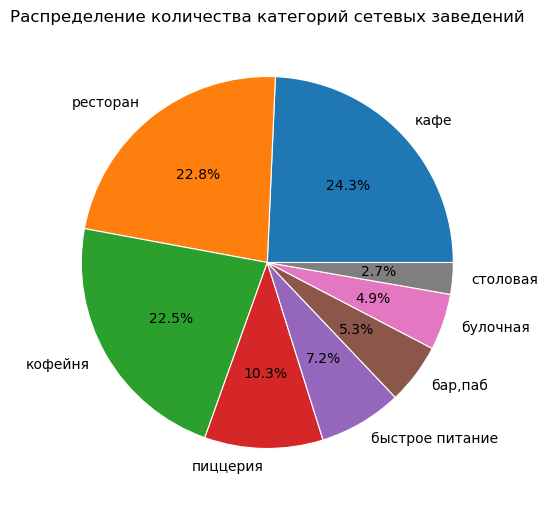

In [41]:
# Визуализируем соотношение категорий сетевых заведений на круговой диаграмме
task_chain_1.sort_values(by=[1], ascending=False)[1].plot(
    autopct='%1.1f%%',
    kind='pie',
    figsize=(6,7),
    ylabel='',
    title='Распределение количества категорий сетевых заведений',
    wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'}  
);

Всего по количеству заведений, не сетевых на 61.7% больше (5198), чем сетевых. 
- Самый большой разрыв в категории "бар, паб" - не сетевых заведений в 3.5 раза больше, чем сетевых. На втором месте категория "столовые" - 2.6 раза. На третьем кафе - 2.1 раза
- В категориях "кофейня" и "пиццерия" количество сетевых и не сетевых заведений почти одинаковое
- В категориях "булочная" сетевых заведений в 1.6 раза больше, чем не сетевых
- Среди всех сетевых заведений ТОП-3 категорий: "кафе" 24.3%, "ресторан" 22.8%, кофейня 22.5%
- Самые не сетевые заведения - это столовые, менее 3%.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Проверим наличие аномальных значений или выбросов? Выведем для каждой категории заведений наиболее типичное для него количество посадочных мест.


In [42]:
# Выведем описательную статистику для датасета по посадочным местам
df['seats'].describe()

count        4792.0
mean     108.361436
std       122.84113
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

In [43]:
# Выводим количество нулевых посадочных мест
(df['seats'] == 0).sum()

np.int64(136)

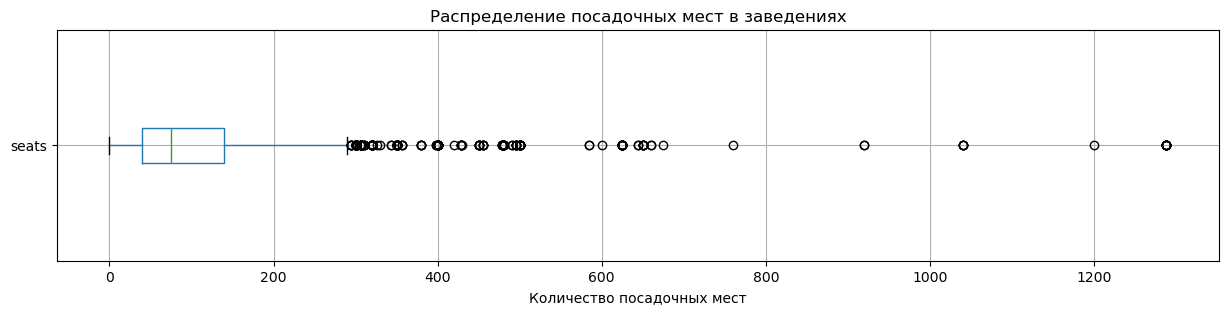

In [44]:
# Визуализируем ящик с усами по данным из датасета df столбца seats (кол-во посадочных мест в заведениях)
plt.figure(figsize=(15, 3))
df.boxplot(column='seats', vert=False)
plt.xlabel('Количество посадочных мест')
plt.title('Распределение посадочных мест в заведениях');

Распределение данных не равномерное, характеризуется большими выбросами в положительной части, они мешают анализу основных данных, поэтому выведем отдельно boxplot без выбросов:

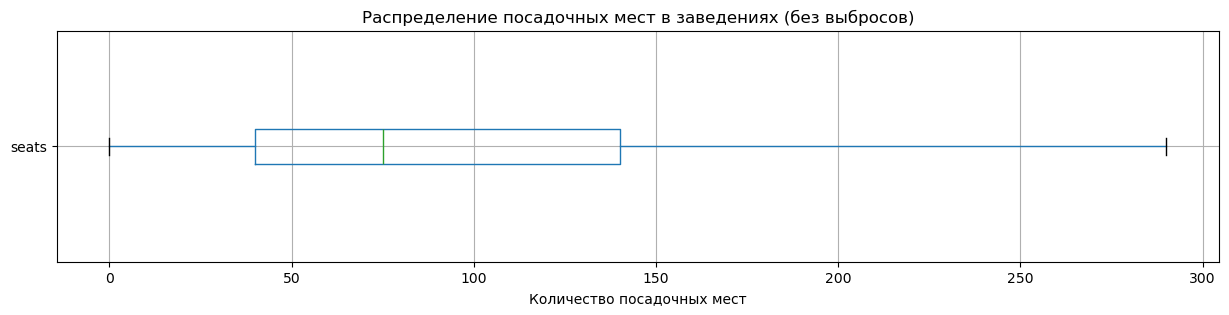

In [45]:
# Визуализируем ящик с усами без выбросов
plt.figure(figsize=(15, 3))
df.boxplot(column='seats', vert=False, showfliers=False)
plt.xlabel('Количество посадочных мест')
plt.title('Распределение посадочных мест в заведениях (без выбросов)');

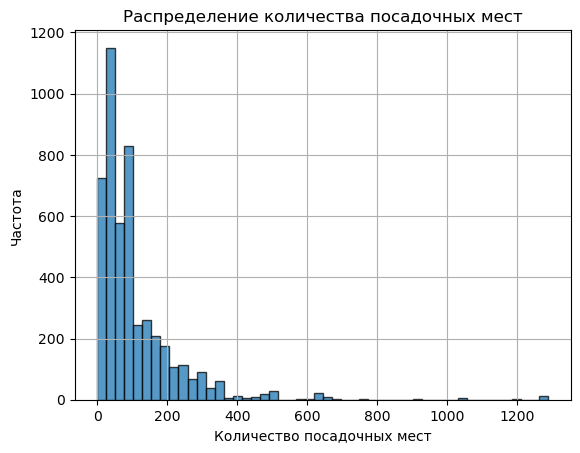

In [46]:
# Представим эти данные на гистограмме
df['seats'].plot(
                kind='hist', 
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                xlabel='Количество посадочных мест',
                ylabel='Частота',
                title='Распределение количества посадочных мест'
)
plt.grid()

Большие выбросы справа не позволяют увидеть картину детализированно, поэтому еще диаграмму с фильтром до 300

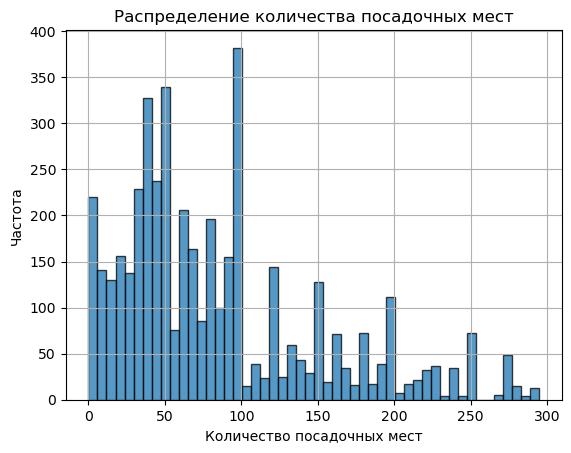

In [47]:
# Выводим гистограмму 
df.loc[df['seats']<300,'seats'].plot(
                kind='hist', 
                bins=50, 
                alpha=0.75,
                edgecolor='black',
                xlabel='Количество посадочных мест',
                ylabel='Частота',
                title='Распределение количества посадочных мест'
)
plt.grid()

In [48]:
# Выводим ТОП-5 количества посадочных мест в заведениях
df['seats'].value_counts().sort_values(ascending=False).head()

seats
40     253
100    213
60     175
50     168
80     160
Name: count, dtype: Int64

In [49]:
# Выведем количество строк, содержащих потенциальные выбросы
df.loc[df['seats']>300,'seats'].value_counts().sum()

np.int64(251)

In [50]:
# Выведем пять строк с самыми большими значениями посадочных мест
df.sort_values('seats',ascending=False).head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
6641,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",Западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288,NaN,NaN,NaN,NaN,False
6524,c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"москва, проспект вернадского, 121, корп. 1",Западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,1288,выше среднего,Средний счёт:1500 ₽,1500.0,NaN,False
6684,6287fb9811434558a4ada0ae08be9c04,пивной ресторан,"бар,паб","москва, проспект вернадского, 121, корп. 1",Западный административный округ,NaN,4.5,0,1288,NaN,NaN,NaN,NaN,False
6658,19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","москва, проспект вернадского, 97, корп. 1",Западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,0,1288,средние,Средний счёт:700 ₽,700.0,NaN,False
6771,6f85ea6419c941208f7deee9194383e1,точка,кафе,"москва, проспект вернадского, 84, стр. 1",Западный административный округ,NaN,4.7,1,1288,NaN,NaN,NaN,NaN,False


In [51]:
# Выведем для каждой категории заведений наиболее типичное для него количество посадочных мест
df.groupby('category')['seats'].median()

category
бар,паб            82.5
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: Float64

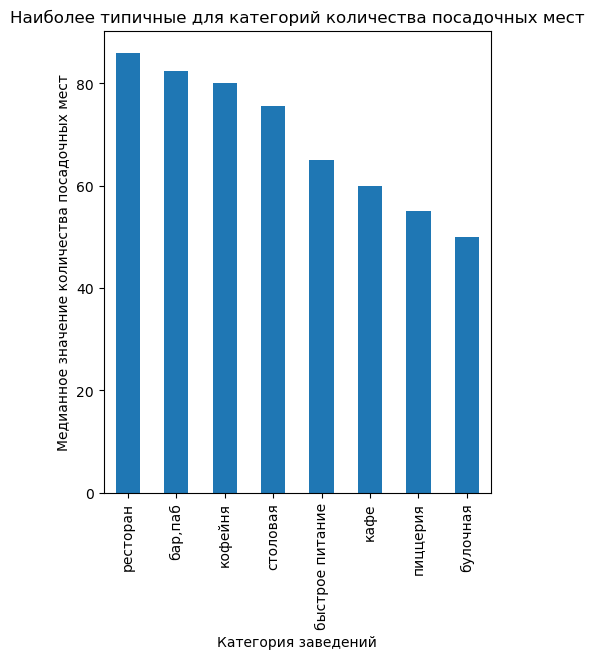

In [52]:
#  Визуализируем на диаграмме полученные значения
df.groupby('category')['seats'].median().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(5,6),
    xlabel='Категория заведений',
    ylabel='Медианное значение количества посадочных мест',
    title='Наиболее типичные для категорий количества посадочных мест'
);

In [53]:
df.groupby('category')['seats'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",468.0,124.532051,145.011574,0.0,48.0,82.5,150.0,1288.0
булочная,148.0,89.385135,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891117,106.611739,0.0,28.0,65.0,140.0,1040.0
кафе,1217.0,97.365653,117.922464,0.0,35.0,60.0,120.0,1288.0
кофейня,751.0,111.199734,127.837772,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496487,112.282703,0.0,30.0,55.0,120.0,1288.0
ресторан,1268.0,121.869874,123.838539,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.75,122.951453,0.0,40.0,75.5,117.0,1200.0


- Данные в столбце `seats` имеют большие выбросы. С высокой долей вероятности часть из выбросов являются аномальными, потому что более тысячи посадочных мест это уже больше похоже на концертный зал, а не на кофейню или бар.
- Распределение данных по количеству мест не равномерное, смещено в положительную сторону.
- Минимальное значение посадочных мест в датасете равно 0 - это заведения, работающие "на вынос" (136 заведений). Медианное значение количества посадочных мест по всем заведениям - 75.
- ТОП-3 по количеству посадочных мест в Москве - 40 мест (253 заведения), 100 мест (213 заведений), 60 мест (175 заведений)
- В среднем, больше всего посадочных мест в категории "ресторан" - 86 мест. Меньше всего в категории "булочная" - 50 мест.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [54]:
df['rating'].describe()

count    8403.000000
mean        4.229894
std         0.470426
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

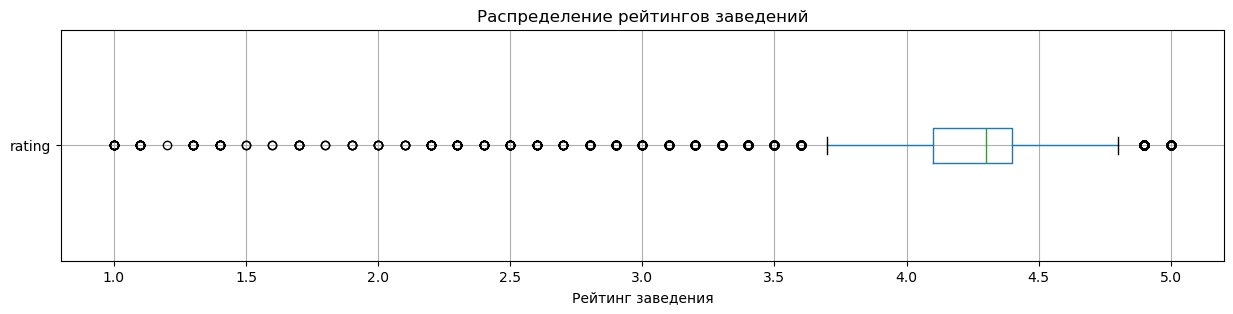

In [55]:
# Визуализируем ящик с усами по данным из датасета df столбца rating
plt.figure(figsize=(15, 3))
df.boxplot(column='rating', vert=False)
plt.xlabel('Рейтинг заведения')
plt.title('Распределение рейтингов заведений');

Распределение данных не равномерное, характеризуется большими выбросами в отрицательной части

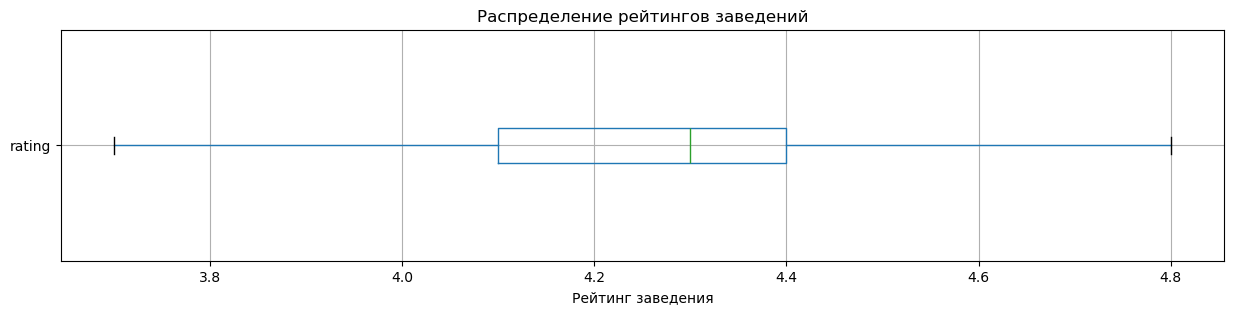

In [56]:
# Визуализируем ящик с усами по данным из датасета df столбца rating без выбросов
plt.figure(figsize=(15, 3))
df.boxplot(column='rating', vert=False, showfliers=False)
plt.xlabel('Рейтинг заведения')
plt.title('Распределение рейтингов заведений');

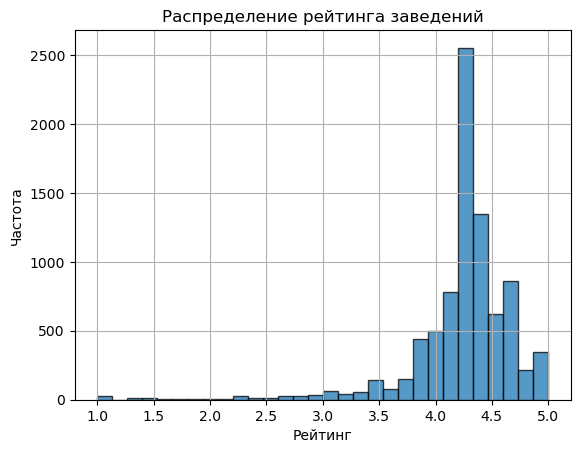

In [57]:
# Выводим диаграмму 
df['rating'].plot(
                kind='hist', 
                bins=30, 
                alpha=0.75,
                edgecolor='black',
                xlabel='Рейтинг',
                ylabel='Частота',
                title='Распределение рейтинга заведений'
)
plt.grid()

In [58]:
# Проведем анализ рейтингов по категориям заведений
df.groupby('category')['rating'].mean().sort_values(ascending=False)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123896
быстрое питание    4.050249
Name: rating, dtype: float64

Средний рейтинг по всем заведениям - 4.3 и распределяется в основном от 4.1 до 4.4. У категорий "бар, паб" средний рейтинг немнго выше, но незначительно. Можно заключить, что от категории заведения рейтинг никак не зависит. 

---

### Задача 6

Изучим с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберим самую сильную связь и проверим её.

In [59]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['rating','category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
correlation_matrix

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.189864,0.200701,0.108340,0.000000,0.220295,0.150210
category,0.189864,1.000000,0.174474,0.265532,0.048265,0.566933,0.244785
district,0.200701,0.174474,1.000000,0.064431,0.352440,0.202787,0.076370
chain,0.108340,0.265532,0.064431,1.000000,0.057584,0.218211,0.043274
seats,0.000000,0.048265,0.352440,0.057584,1.000000,0.088146,0.043193
price,0.220295,0.566933,0.202787,0.218211,0.088146,1.000000,0.084183
is_24_7,0.150210,0.244785,0.076370,0.043274,0.043193,0.084183,1.000000


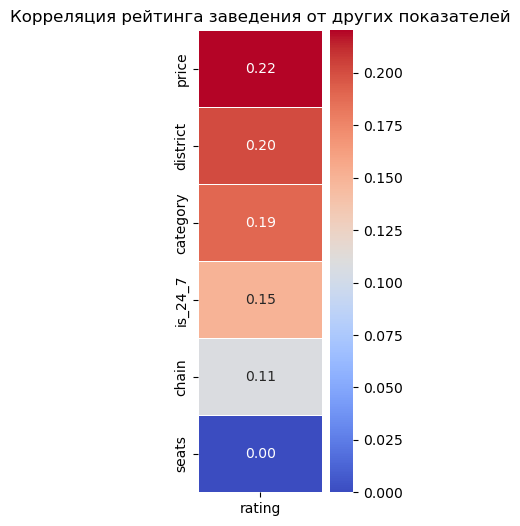

In [60]:
# Строим хитмап корреляции `rating` с другими параметрами
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
# Строим тепловую карту
plt.figure(figsize=(2, 6))
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5 # Форматируем линию между ячейками карты
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Корреляция рейтинга заведения от других показателей')
plt.xlabel('')

# Выводим график
plt.show()

In [61]:
# Проверяем корреляцию между `price` и `rating`
df.groupby('price')['rating'].mean()

price
высокие          4.436611
выше среднего    4.386348
низкие           4.173077
средние          4.297874
Name: rating, dtype: float64

(0.0, 8000.0)

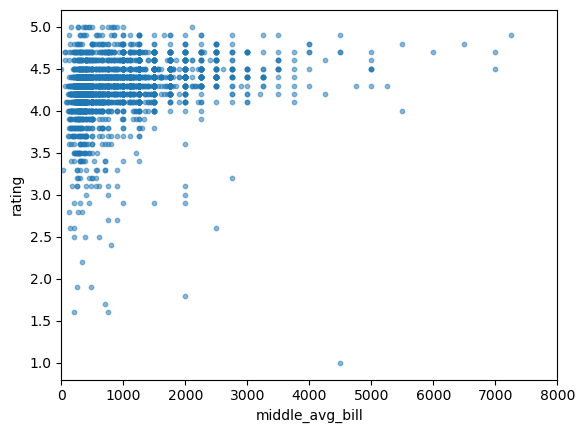

In [62]:
# Выводим scatter-график зависимости средней цены и рейтинга
sx=df.plot(
    kind='scatter',
    x='middle_avg_bill',
    y='rating',
    s=10,
    alpha=0.5
)
sx.set_xlim(0,8000)

- `rating` сильнее всего коррелирует с `price`, но эта зависимость тоже не достаточно сильная, чтобы строить на этом какую-то гипотезу. Самый высокий средний рейтинг у заведений с категорией цен "выше среднего" - 4.39, самый низкий у "низкие" - 4.17
- Анализ показал, что рейтинг заведений не имеет сильных корреляций от представленных в датасете данных. 

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. Определим к какой категории заведений они относятся.

In [63]:
# Группируем по name и считаем кол-во повторений
task_7 = df[df['chain'] == 1].groupby('name').agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean'),
    category=('category', 'first')
).sort_values('count', ascending=False).head(15)
task_7

,count,avg_rating,category
name,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,76,4.169737,пиццерия
додо пицца,74,4.286486,пиццерия
one price coffee,71,4.064789,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,быстрое питание
кофепорт,42,4.147619,кофейня


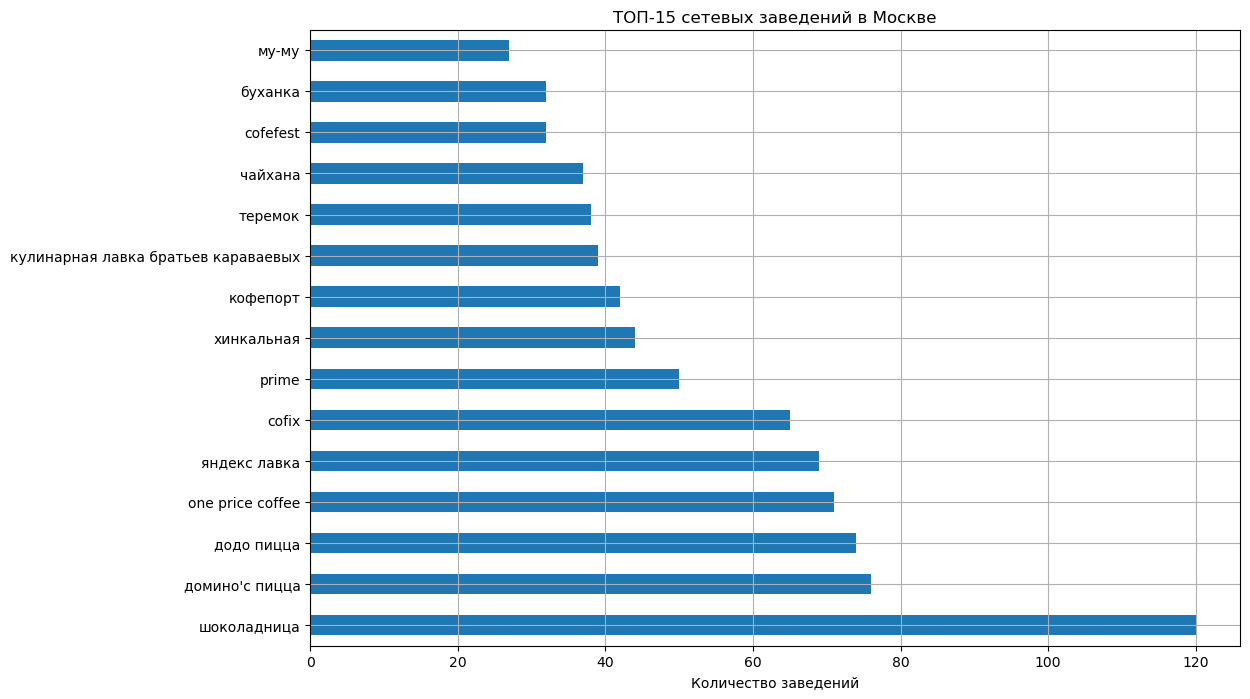

In [64]:
# Отобразим на диаграмме полученные значения
task_7['count'].plot(
    kind='barh',
    grid=True,
    figsize=(12,8),
    xlabel='Количество заведений',
    ylabel='',
    title='ТОП-15 сетевых заведений в Москве'    
);

In [65]:
# Выводим самые популярные категории из ТОП-15 сетевых заведений
task_7['category'].value_counts()

category
кофейня            5
ресторан           3
кафе               3
пиццерия           2
быстрое питание    1
булочная           1
Name: count, dtype: int64

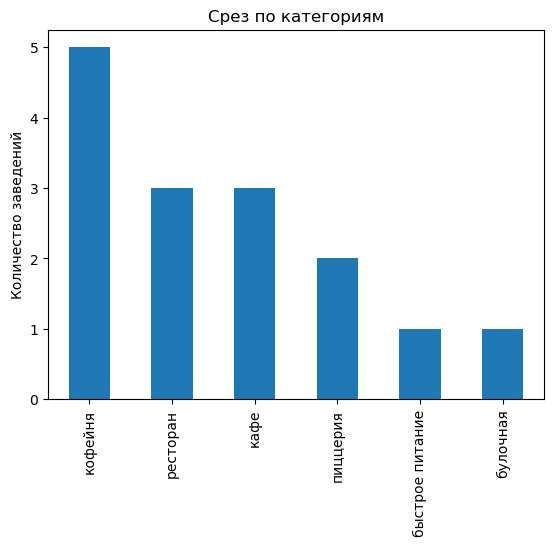

In [66]:
task_7['category'].value_counts().plot(
    kind='bar',
    xlabel='',
    ylabel='Количество заведений',
    title='Срез по категориям'
);

In [67]:
# Выводим сортировку по рейтингу заведений ТОП-15
task_7.sort_values('avg_rating', ascending=False)

,count,avg_rating,category
name,,,
буханка,32,4.396875,булочная
кулинарная лавка братьев караваевых,39,4.394872,кафе
хинкальная,44,4.322727,быстрое питание
додо пицца,74,4.286486,пиццерия
му-му,27,4.229630,кафе
шоколадница,120,4.177500,кофейня
домино'с пицца,76,4.169737,пиццерия
кофепорт,42,4.147619,кофейня
теремок,38,4.123684,ресторан


- ТОП-3 сетевых заведений из представленных данных: Шоколадница (120 заведений), Домино'с пицца (76), Додо пицца (74). Шоколадница идет с большим отрывом в 44 заведения.
- Самая попопулярная категория из ТОП-15 - кофейня, в ней представлено 5 заведений (шоколадница, кофепорт, cofix, one price coffee, cofefest). Самые не популярные категории - булочная и быстрое питание (по 1 заведению)
- Самый высокий средний рейтинг по заведениям из списка ТОП-15 имеет Буханка и Кулинарная лавка братьев караваевых - ср. рейтинг 4.4. Самый низкий - Яндекс лавка (3.8).

---

### Задача 8

Изучим вариации среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Проанализируем как удалённость от центра влияет на цены в заведениях.


In [68]:
# Выведем средний чек для каждого района Москвы
task_8=df.groupby('district')['middle_avg_bill'].mean().round(0).sort_values(ascending=False)
task_8

district
Центральный административный округ         1191.0
Западный административный округ            1053.0
Северный административный округ             928.0
Южный административный округ                834.0
Северо-Западный административный округ      822.0
Восточный административный округ            821.0
Юго-Западный административный округ         793.0
Северо-Восточный административный округ     717.0
Юго-Восточный административный округ        654.0
Name: middle_avg_bill, dtype: float64

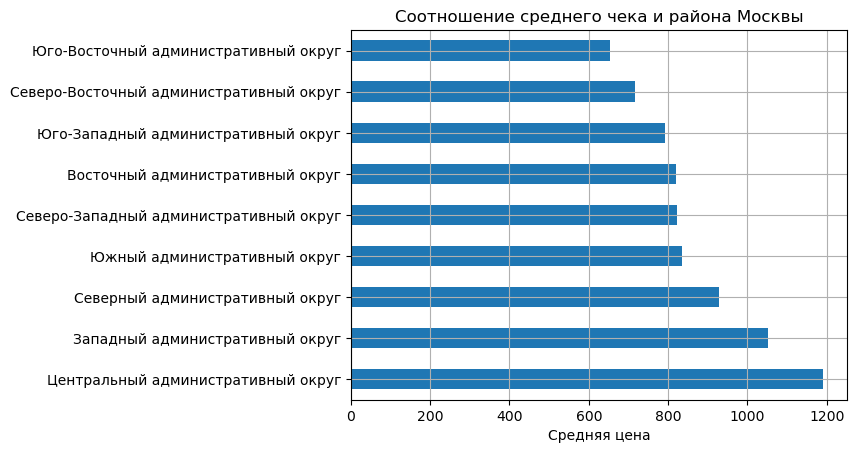

In [69]:
# Визуализируем зависимость на диаграмме
task_8.plot(
    kind='barh',
    xlabel='Средняя цена',
    ylabel='',
    title='Соотношение среднего чека и района Москвы',
    grid=True
);

In [70]:
# Проведем анализ среднего чека в ЦАО
task_8_centr=df[df['district']=='Центральный административный округ'].groupby('category')['middle_avg_bill'].mean().sort_values(ascending=False)
task_8_centr

category
ресторан           1561.059113
бар,паб            1479.739884
булочная           1237.916667
пиццерия           1104.839506
кофейня             794.764706
кафе                765.176190
быстрое питание     532.081633
столовая            319.886364
Name: middle_avg_bill, dtype: float64

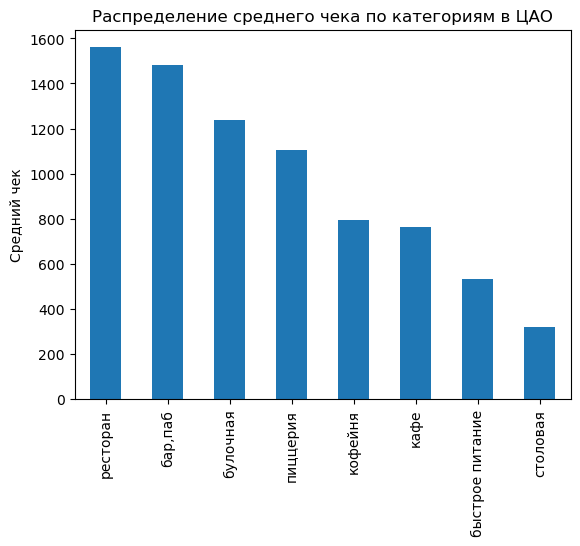

In [71]:
# Представим данные на диаграмме
task_8_centr.plot(
    kind='bar',
    xlabel='',
    ylabel='Средний чек',
    title='Распределение среднего чека по категориям в ЦАО'
);

In [72]:
# Выведем категории и округа с максимальными средними чеками 
task_8_all=df.groupby(['category', 'district'])['middle_avg_bill'].mean().round(0).reset_index()
task_8_max=task_8_all.loc[task_8_all.groupby('category')['middle_avg_bill'].idxmax()]
task_8_max=task_8_max.reset_index(drop=True)
task_8_max

,category,district,middle_avg_bill
0,"бар,паб",Северный административный округ,1573.0
1,булочная,Центральный административный округ,1238.0
2,быстрое питание,Восточный административный округ,832.0
3,кафе,Западный административный округ,827.0
4,кофейня,Центральный административный округ,795.0
5,пиццерия,Центральный административный округ,1105.0
6,ресторан,Центральный административный округ,1561.0
7,столовая,Западный административный округ,565.0


In [73]:
# Выведем категории и округа с минимальными средними чеками 
task_8_min=task_8_all.loc[task_8_all.groupby('category')['middle_avg_bill'].idxmin()]
task_8_min=task_8_min.reset_index(drop=True)
task_8_min

,category,district,middle_avg_bill
0,"бар,паб",Северо-Восточный административный округ,987.0
1,булочная,Северо-Западный административный округ,200.0
2,быстрое питание,Северо-Западный административный округ,295.0
3,кафе,Юго-Восточный административный округ,589.0
4,кофейня,Юго-Восточный административный округ,263.0
5,пиццерия,Юго-Восточный административный округ,562.0
6,ресторан,Юго-Восточный административный округ,932.0
7,столовая,Юго-Восточный административный округ,289.0


- ТОП-3 самых высоких средних чека по всем заведениям в Москве: ЦАО - 1191, ЗАО - 1053, САО - 928.
- Самый низкий средний чек по всем заведениям в ЮВАО - 654.
- В ЦАО самый высокий средний чек в категории "ресторан" - 1561, самый низкий в категории "столовая" - 319.
- В ЦАО находятся заведения с самым высоким средним чеком в категориях "ресторан", "пиццерия", "кофейня", "булочная"
- В ЗАО находятся заведения с самым высоким средним чеком в категориях "кафе" и "столовая"
- Самые высокие средие чеки из категории "бар, паб" расположились в САО
- Самые высокие средие чеки из категории "быстрое питание" расположились в САО

---

### Промежуточный вывод

- В ходе исследования были определены самые популярные категории заведений в Москве - "кафе" (28.3%) и "ресторан" (24.3%)
- Среди административных округов по количеству заведений лидирует ЦАО (26.7%)
- Не сетевых заведений в Москве на 61.7% больше, чем сетевых. Самая популярная категория сетевых заведений - "кафе" (24.3%)
- Больше всего посадочных мест в категории «ресторан» - 86 мест, меньше всего в «булочная» - 50
- Рейтинги заведений не имеет сильных корреляций от представленных в датасете данных
- Самое популярное сетевое заведение в москве - Шоколадница (120 заведений), а самый высокий рейтинг из сетевых заведений у Буханки и Кулинарной лавки братьев караванных - 4.4.
- Самый высокий средний чек в заведениях "ресторан" в Центральном административном округе - 1561.

## Итоговый вывод и рекомендации

В ходе исследования были проанализированы 8406 заведений общественного питания по 9 районам города Москвы. Данные включали названия заведений, часы работы, рейтинг и средний чек. Все заведения были разбиты на категории и округа. Акцент исследования был сделан на категориях заведений, их локациях и средних ценах.

В Москве по количеству заведений лидируют категории "кафе" (28.3%) и "рестораны" (24.3%).

Большинство заведений расположено в ЦАО (26.7%), остальные 8 районов распределены почти равномерно. За исключением СЗАО, в котором расположены всего 4.8% заведений.
В ЦАО в основном представлены рестораны (29.8%), кафе (20.7%) и кофейни (19.1%).

Не сетевых заведений на 61.7% больше. Самый большой разрыв в категории «бар, паб» - не сетевых заведений здесь в 3.5 раза больше. Если же рассматривать категории «кофейня» и «пиццерия», то здесь количество сетевых и не сетевых заведений одинаковое. 
ТОП-3 категорий сетевых заведений в Москве: «кафе» (24.3%), «ресторан» (22.8%) и «кофейня» (22.5%).

Медианное значение посадочных мест во всех заведениях - 75 мест. Больше всего посадочных мест в категории «ресторан» - 86 мест, меньше всего в «булочная» - 50. Часть заведений (136) работают на вынос и не имеют посадочных мест. 

Все заведения имеют примерно одинаковый разброс среднего рейтинга от 4.1 до 4.4 и он не зависит от района, категории, режима работы или цен.

ТОП-3 сетевых заведений по количеству открытых точек в Москве - Шоколадница (120 заведений), Домино'с пицца (76), Додо пицца (74).
Самый высокий рейтинг из сетевых заведений у Буханки и Кулинарной лавки братьев караванных - 4.4.

ТОП-3 района самых высоких средних чеков по всем заведениям в Москве: ЦАО - 1191, ЗАО - 1053, САО - 928.
В ЦАО находятся заведения с самым высоким средним чеком в категориях "ресторан", "пиццерия", "кофейня" и "булочная». Средний чек в категории "ресторан" - 1561.
В ЮВАО встречаются самые низкие средние чеки в категориях «кофейня», «пиццерия», «ресторан», «столовая».

В качестве рекоммендаций стоит обратить внимание на административные округа с самым высоким средним чеком: Центральный, Западный и Северный. "Ресторан", "пиццерия" и "кофейня" имеют больший средний чек, чем другие категории, но при этом в категориях "пиццерия" и "кофейня" представлены самые крупные сетевые заведения, которые составят большую конкуренцию. В категории "ресторан" в среднем требуется больше всего пасадочных мест и это стоит учитывать при расчете инвестиций. Количество сетевых заведений в категории "ресторан" на втором месте после "кафе", но при этом ни одна из сетей по количеству точек не входит в ТОП-5. Возможно, это стоит рассмотреть как точку дальнейшего роста.